# Local-Level Regression — Mixed Model (Milton + Helene)

**Prerequisite**: Run `local_metrics.ipynb` to generate metrics CSVs.

**Purpose**: Pool Milton county-level and Helene cluster-level results into a
mixed model to test socioeconomic predictors of disruption and recovery.

**Y variables** (7):
- largest_drop_within, recovery_days_within, total_disruption_within
- largest_drop_inflow, recovery_days_inflow, total_disruption_inflow
- largest_increase_outflow

**X variables**:
- hurricane (helene=0, milton=1)
- coastal (1/0, from coastline intersection)
- median_household_income
- pct_no_vehicle
- pct_white
- nchs_code (1-6, numeric)
- total_population
- population_density
- dist_to_track_mi

**Models**:
- Model A: all X features + insurance_coverage_pct
- Model B: all X features, no insurance
- Model C: Model A excluding Okeechobee (test insurance robustness)

Note: pct_bachelors_plus excluded (r=0.97 with income).

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import warnings

import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, pearsonr

warnings.filterwarnings('ignore')

LOCAL_ROOT = '../results/local_level'
OUTPUT_DIR = f'{LOCAL_ROOT}/regression'
os.makedirs(f'{OUTPUT_DIR}/figures', exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Derive Coastal Flag from Shapefile

In [2]:
# ── Coastal flag: compute once and cache ──
COASTAL_CACHE = f'{LOCAL_ROOT}/coastal_flags.csv'

if os.path.exists(COASTAL_CACHE):
    print(f'Loading cached coastal flags from {COASTAL_CACHE}')
    coastal_df = pd.read_csv(COASTAL_CACHE)
    coastal_df['GEOID'] = coastal_df['GEOID'].astype(int)
else:
    print('Computing coastal flags from shapefiles (first run only)...')
    
    # Load county geometries
    county_shp = './../../hurricane_oct/data/county_geo/tl_2023_us_county/tl_2023_us_county.shp'
    counties_gdf = gpd.read_file(county_shp)
    counties_gdf['GEOID'] = counties_gdf['GEOID'].astype(int)
    
    # Load coastline
    coast_shp = './../../hurricane_oct/data/county_geo/ne_10m_coastline/ne_10m_coastline.shp'
    coastline = gpd.read_file(coast_shp)
    
    # Project to EPSG:5070
    counties_proj = counties_gdf.to_crs(epsg=5070)
    coastline_proj = coastline.to_crs(epsg=5070)
    coast_union = coastline_proj.unary_union
    
    # Flag: county boundary touches coastline (100m buffer for precision)
    counties_proj['is_coastal'] = counties_proj.geometry.intersects(coast_union.buffer(100)).astype(int)
    
    # Area for population density
    counties_proj['ALAND'] = counties_proj['ALAND'].astype(float)
    counties_proj['area_sq_mi'] = counties_proj['ALAND'] / 2.59e6
    
    # Export
    coastal_df = counties_proj[['GEOID', 'is_coastal', 'area_sq_mi']].copy()
    coastal_df = pd.DataFrame({'GEOID': coastal_df['GEOID'].values,
                               'is_coastal': coastal_df['is_coastal'].values,
                               'area_sq_mi': coastal_df['area_sq_mi'].values})
    coastal_df.to_csv(COASTAL_CACHE, index=False)
    print(f'  Saved to {COASTAL_CACHE}')

# Verify with Milton counties
geo_idx = pd.read_csv('geoid_idx_names.csv')
geo_idx['GEOID'] = geo_idx['GEOID'].astype(int)

with open(f'{LOCAL_ROOT}/milton/counties_geoid_cut_50.txt') as f:
    milton_geoids = [int(l.strip()) for l in f]

milton_coastal = coastal_df[coastal_df['GEOID'].isin(milton_geoids)].merge(
    geo_idx[['GEOID', 'NAME']], on='GEOID')
print('\nMilton coastal counties:')
print(milton_coastal[['NAME', 'GEOID', 'is_coastal']].sort_values('is_coastal', ascending=False).to_string(index=False))
print(f'\nCoastal: {milton_coastal["is_coastal"].sum()} / {len(milton_coastal)}')

Computing coastal flags from shapefiles (first run only)...
  Saved to ../results/local_level/coastal_flags.csv

Milton coastal counties:
        NAME  GEOID  is_coastal
    Hernando  12053           1
       Pasco  12101           1
Hillsborough  12057           1
Indian River  12061           1
     Brevard  12009           1
    Sarasota  12115           1
         Lee  12071           1
     Volusia  12127           1
   Charlotte  12015           1
    Pinellas  12103           1
     Manatee  12081           1
        Lake  12069           0
    Seminole  12117           0
        Polk  12105           0
      DeSoto  12027           0
     Osceola  12097           0
      Hardee  12049           0
  Okeechobee  12093           0
   Highlands  12055           0
      Orange  12095           0
      Sumter  12119           0

Coastal: 11 / 21


## 2. Build Combined Dataset

In [3]:
# ── Load ACS ──
acs = pd.read_csv('acs_socioeconomic_v2.csv')
acs['GEOID'] = acs['GEOID'].astype(int)

# ── Load NCHS ──
nchs = pd.read_csv('../data/NCHS Urban-Rural Classification Scheme for Counties.csv', encoding='utf-8-sig')
nchs['GEOID'] = nchs['Location'].astype(int)
nchs['nchs_code'] = nchs['2023 Code'].str.extract(r'(\d)').astype(int)

# ══════════════════════════════════════════
# MILTON: county-level
# ══════════════════════════════════════════
def load_milton_data():
    milton_dir = f'{LOCAL_ROOT}/milton'
    
    # Load metrics
    dfs = {}
    for ft in ['within', 'inflow', 'outflow']:
        path = f'{milton_dir}/metrics_{ft}.csv'
        if os.path.exists(path):
            dfs[ft] = pd.read_csv(path)
            dfs[ft]['unit_id'] = dfs[ft]['unit_id'].astype(int)
    
    # Merge all flow types
    df = dfs['within'][['unit_id', 'largest_drop', 'recovery_days', 'total_disruption']].rename(
        columns={'largest_drop': 'largest_drop_within', 'recovery_days': 'recovery_days_within',
                 'total_disruption': 'total_disruption_within'})
    
    if 'inflow' in dfs:
        df = df.merge(
            dfs['inflow'][['unit_id', 'largest_drop', 'recovery_days', 'total_disruption']].rename(
                columns={'largest_drop': 'largest_drop_inflow', 'recovery_days': 'recovery_days_inflow',
                         'total_disruption': 'total_disruption_inflow'}),
            on='unit_id', how='left')
    
    if 'outflow' in dfs:
        df = df.merge(
            dfs['outflow'][['unit_id', 'largest_increase']].rename(
                columns={'largest_increase': 'largest_increase_outflow'}),
            on='unit_id', how='left')
    
    # Merge features
    df = df.rename(columns={'unit_id': 'GEOID'})
    df = df.merge(acs[['GEOID', 'total_population', 'median_household_income',
                       'pct_no_vehicle', 'insurance_coverage_pct', 'pct_white']], on='GEOID')
    df = df.merge(nchs[['GEOID', 'nchs_code']], on='GEOID', how='left')
    df = df.merge(coastal_df[['GEOID', 'is_coastal', 'area_sq_mi']], on='GEOID', how='left')
    df = df.merge(geo_idx[['GEOID', 'NAME']], on='GEOID', how='left')
    
    # Distance to track
    dist = pd.read_csv(f'{milton_dir}/county_distance_to_track.csv')
    dist['GEOID'] = dist['GEOID'].astype(int)
    df = df.merge(dist[['GEOID', 'dist_to_track_mi']], on='GEOID', how='left')
    
    # Population density
    df['pop_density'] = df['total_population'] / df['area_sq_mi']
    
    df['hurricane'] = 'milton'
    df['hurricane_cat'] = 5
    return df

# ══════════════════════════════════════════
# HELENE: cluster-level
# ══════════════════════════════════════════
def load_helene_data():
    helene_dir = f'{LOCAL_ROOT}/helene'
    
    # Load cluster assignments for feature computation
    cluster_df = pd.read_csv(f'{helene_dir}/county_cluster_assignments.csv')
    cluster_df['GEOID'] = cluster_df['GEOID'].astype(int)
    
    # Merge ACS columns NOT already in cluster_df
    # cluster_df already has: GEOID, NAME, cluster, nchs_code, nchs_label,
    #   median_household_income, total_population, dist_to_track_mi, largest_drop
    extra_acs_cols = ['GEOID', 'pct_no_vehicle', 'insurance_coverage_pct',
                      'pct_white', 'white_pop', 'bachelors_plus_count']
    cluster_df = cluster_df.merge(acs[extra_acs_cols], on='GEOID', how='left')
    # nchs_code already in cluster_df — skip NCHS merge
    cluster_df = cluster_df.merge(coastal_df[['GEOID', 'is_coastal', 'area_sq_mi']], on='GEOID', how='left')
    
    # Aggregate to cluster level
    cluster_features = cluster_df.groupby('cluster').apply(
        lambda g: pd.Series({
            'total_population': g['total_population'].sum(),
            'median_household_income': g['median_household_income'].median(),
            'pct_no_vehicle': g['pct_no_vehicle'].median(),
            'insurance_coverage_pct': g['insurance_coverage_pct'].median(),
            'pct_white': g['white_pop'].sum() / g['total_population'].sum() * 100
                if g['total_population'].sum() > 0 else None,
            'nchs_code': g['nchs_code'].mode().iloc[0] if len(g['nchs_code'].mode()) > 0 else None,
            'is_coastal': int(g['is_coastal'].any()),  # 1 if ANY county in cluster is coastal
            'area_sq_mi': g['area_sq_mi'].sum(),
            'dist_to_track_mi': g['dist_to_track_mi'].mean(),
            'n_counties': len(g),
        })
    ).reset_index()
    cluster_features['pop_density'] = cluster_features['total_population'] / cluster_features['area_sq_mi']
    
    # Load metrics
    dfs = {}
    for ft in ['within', 'inflow', 'outflow']:
        path = f'{helene_dir}/metrics_{ft}.csv'
        if os.path.exists(path):
            dfs[ft] = pd.read_csv(path)
            dfs[ft]['unit_id'] = dfs[ft]['unit_id'].astype(int)
    
    # Merge metrics
    df = dfs['within'][['unit_id', 'largest_drop', 'recovery_days', 'total_disruption']].rename(
        columns={'unit_id': 'cluster', 'largest_drop': 'largest_drop_within',
                 'recovery_days': 'recovery_days_within',
                 'total_disruption': 'total_disruption_within'})
    
    if 'inflow' in dfs:
        df = df.merge(
            dfs['inflow'][['unit_id', 'largest_drop', 'recovery_days', 'total_disruption']].rename(
                columns={'unit_id': 'cluster', 'largest_drop': 'largest_drop_inflow',
                         'recovery_days': 'recovery_days_inflow',
                         'total_disruption': 'total_disruption_inflow'}),
            on='cluster', how='left')
    
    if 'outflow' in dfs:
        df = df.merge(
            dfs['outflow'][['unit_id', 'largest_increase']].rename(
                columns={'unit_id': 'cluster', 'largest_increase': 'largest_increase_outflow'}),
            on='cluster', how='left')
    
    # Merge features
    df = df.merge(cluster_features, on='cluster', how='left')
    df['NAME'] = 'Cluster_' + df['cluster'].astype(str)
    df['hurricane'] = 'helene'
    df['hurricane_cat'] = 4
    
    return df

print('Functions defined.')

Functions defined.


In [4]:
# ── Load and combine ──
df_milton = load_milton_data()
df_helene = load_helene_data()

print(f'Milton: {len(df_milton)} counties')
print(f'Helene: {len(df_helene)} clusters')

# Standardize columns for pooling
common_cols = ['NAME', 'hurricane', 'hurricane_cat',
               'total_population', 'median_household_income',
               'pct_no_vehicle', 'insurance_coverage_pct', 'pct_white',
               'nchs_code', 'is_coastal', 'pop_density', 'dist_to_track_mi',
               'largest_drop_within', 'recovery_days_within', 'total_disruption_within',
               'largest_drop_inflow', 'recovery_days_inflow', 'total_disruption_inflow',
               'largest_increase_outflow']
common_cols = [c for c in common_cols if c in df_milton.columns and c in df_helene.columns]

df_pooled = pd.concat([df_milton[common_cols], df_helene[common_cols]], ignore_index=True)
df_pooled['is_milton'] = (df_pooled['hurricane'] == 'milton').astype(int)

print(f'\nPooled: {len(df_pooled)} observations')
print(f'  Milton: {df_pooled["is_milton"].sum()}')
print(f'  Helene: {(~df_pooled["is_milton"].astype(bool)).sum()}')
print(f'  Coastal: {df_pooled["is_coastal"].sum()}')
print(f'  Inland: {(df_pooled["is_coastal"] == 0).sum()}')

# Save pooled dataset
df_pooled.to_csv(f'{OUTPUT_DIR}/pooled_dataset.csv', index=False)
print(f'\nSaved: {OUTPUT_DIR}/pooled_dataset.csv')
display(df_pooled.head())

Milton: 21 counties
Helene: 38 clusters

Pooled: 59 observations
  Milton: 21
  Helene: 38
  Coastal: 14.0
  Inland: 45

Saved: ../results/local_level/regression/pooled_dataset.csv


,NAME,hurricane,hurricane_cat,total_population,median_household_income,pct_no_vehicle,insurance_coverage_pct,pct_white,nchs_code,is_coastal,pop_density,dist_to_track_mi,largest_drop_within,recovery_days_within,total_disruption_within,largest_drop_inflow,recovery_days_inflow,total_disruption_inflow,largest_increase_outflow,is_milton
0,Brevard,milton,5,610723.0,71308.0,4.666937,98.605778,80.919392,3.0,1.0,601.718154,10.315948,-28.337412,5.066932,143.583749,-31.781904,4.608859,146.478313,10.946444,1
1,Charlotte,milton,5,189900.0,62164.0,4.502132,99.023261,88.951518,4.0,1.0,278.807713,43.319139,-47.705129,4.645104,221.595307,-38.883456,3.537823,137.562773,119.167860,1
2,DeSoto,milton,5,34258.0,45000.0,6.199352,98.581973,81.903080,5.0,0.0,53.806252,34.944728,-41.834880,4.635348,193.919243,-30.815381,1.711787,52.749355,-50.736287,1
3,Hardee,milton,5,25528.0,44665.0,4.909561,98.687346,76.771377,6.0,0.0,40.039750,18.407624,-26.405585,4.942319,130.504834,-9.381273,2.089909,19.606011,0.326334,1
4,Hernando,milton,5,196621.0,59202.0,5.065114,98.389251,86.631883,2.0,1.0,415.721403,66.109596,-43.013209,5.621911,241.816426,-26.977993,3.460198,93.349196,46.167875,1


## 3. Feature Summary and Correlations

In [5]:
# ── Feature summary by hurricane ──
X_FEATURES = ['median_household_income', 'pct_no_vehicle', 'pct_white',
              'nchs_code', 'is_coastal', 'total_population', 'pop_density',
              'dist_to_track_mi', 'insurance_coverage_pct']

print('Feature summary by hurricane:')
for hrc in ['milton', 'helene']:
    sub = df_pooled[df_pooled['hurricane'] == hrc]
    print(f'\n{hrc.upper()} (N={len(sub)}):')
    for f in X_FEATURES:
        if f in sub:
            vals = sub[f].dropna()
            print(f'  {f:<30s}: mean={vals.mean():.2f}, med={vals.median():.2f}, '
                  f'std={vals.std():.2f}, range=[{vals.min():.2f}, {vals.max():.2f}]')

# ── Cross-correlation of features ──
print('\n\nFeature cross-correlations (pooled):')
corr = df_pooled[X_FEATURES + ['is_milton']].corr().round(3)
display(corr)

Feature summary by hurricane:

MILTON (N=21):
  median_household_income       : mean=64236.14, med=66239.00, std=9462.53, range=[44665.00, 79490.00]
  pct_no_vehicle                : mean=4.82, med=4.82, std=0.89, range=[3.16, 6.90]
  pct_white                     : mean=79.38, med=80.92, std=7.77, range=[59.87, 89.68]
  nchs_code                     : mean=3.00, med=3.00, std=1.38, range=[1.00, 6.00]
  is_coastal                    : mean=0.52, med=1.00, std=0.51, range=[0.00, 1.00]
  total_population              : mean=480055.05, med=405069.00, std=414746.14, range=[25528.00, 1468560.00]
  pop_density                   : mean=707.30, med=415.72, std=794.32, range=[40.04, 3506.16]
  dist_to_track_mi              : mean=35.11, med=41.48, std=20.32, range=[1.68, 66.11]
  insurance_coverage_pct        : mean=98.53, med=98.55, std=0.37, range=[97.36, 99.08]

HELENE (N=38):
  median_household_income       : mean=55019.92, med=54187.25, std=8997.68, range=[42012.50, 82056.00]
  pct_no_vehi

,median_household_income,pct_no_vehicle,pct_white,nchs_code,is_coastal,total_population,pop_density,dist_to_track_mi,insurance_coverage_pct,is_milton
median_household_income,1.000,-0.458,-0.033,-0.664,0.336,0.360,0.521,-0.066,0.145,0.440
pct_no_vehicle,-0.458,1.000,-0.395,0.218,-0.091,-0.106,-0.014,0.015,-0.288,-0.303
pct_white,-0.033,-0.395,1.000,0.288,0.048,-0.355,-0.186,0.242,0.377,-0.042
nchs_code,-0.664,0.218,0.288,1.000,-0.439,-0.572,-0.755,0.094,-0.055,-0.654
is_coastal,0.336,-0.091,0.048,-0.439,1.000,0.213,0.392,0.021,-0.038,0.501
total_population,0.360,-0.106,-0.355,-0.572,0.213,1.000,0.355,-0.125,0.106,0.063
pop_density,0.521,-0.014,-0.186,-0.755,0.392,0.355,1.000,-0.062,0.085,0.475
dist_to_track_mi,-0.066,0.015,0.242,0.094,0.021,-0.125,-0.062,1.000,0.152,-0.095
insurance_coverage_pct,0.145,-0.288,0.377,-0.055,-0.038,0.106,0.085,0.152,1.000,-0.044
is_milton,0.440,-0.303,-0.042,-0.654,0.501,0.063,0.475,-0.095,-0.044,1.000


## 4. Mixed Model: OLS with Hurricane Fixed Effect

Three model specifications:
- **Model A**: All X + insurance_coverage_pct
- **Model B**: All X, no insurance
- **Model C**: Model A, excluding Okeechobee (GEOID 12093)

In [9]:
# ── Define DVs and model specs ──
DV_CONFIGS = {
    'largest_drop_within': 'Largest Drop — Within (%)',
    'recovery_days_within': 'Recovery Time — Within (days)',
    'total_disruption_within': 'Total Disruption — Within',
    'largest_drop_inflow': 'Largest Drop — Inflow (%)',
    'recovery_days_inflow': 'Recovery Time — Inflow (days)',
    'total_disruption_inflow': 'Total Disruption — Inflow',
    'largest_increase_outflow': 'Outflow Increase (%)',
}

X_BASE = ['is_milton', 'is_coastal', 'median_household_income',
          'pct_no_vehicle', 'pct_white', 'nchs_code',
          'total_population', 'pop_density', 'dist_to_track_mi']

MODEL_SPECS = {
    'A': {'features': X_BASE + ['insurance_coverage_pct'], 'data': df_pooled,
          'label': 'Model A: all features + insurance'}}
#     'B': {'features': X_BASE, 'data': df_pooled,
#           'label': 'Model B: no insurance'},
#     'C': {'features': X_BASE + ['insurance_coverage_pct'],
#           'data': df_pooled[~((df_pooled['hurricane'] == 'milton') & (df_pooled['NAME'] == 'Okeechobee'))].copy(),
#           'label': 'Model C: with insurance, excl. Okeechobee'},
# }

In [10]:
# ── Run all models ──
all_ols_results = []

for dv_col, dv_label in DV_CONFIGS.items():
    print(f"\n{'='*80}")
    print(f'DV: {dv_label}')
    print(f"{'='*80}")
    
    for model_key, spec in MODEL_SPECS.items():
        features = spec['features']
        data = spec['data']
        label = spec['label']
        
        # Drop rows with NaN in DV or features
        df_valid = data.dropna(subset=[dv_col] + features).copy()
        
        if len(df_valid) < len(features) + 2:
            print(f'  {label}: only {len(df_valid)} obs — skipping')
            continue
        
        # Standardize continuous features
        continuous = [f for f in features if f not in ['is_milton', 'is_coastal']]
        scaler = StandardScaler()
        X_z = pd.DataFrame(
            scaler.fit_transform(df_valid[continuous]),
            columns=continuous, index=df_valid.index)
        # Add binary features unstandardized
        for bf in ['is_milton', 'is_coastal']:
            if bf in features:
                X_z[bf] = df_valid[bf].values
        X = sm.add_constant(X_z)
        y = df_valid[dv_col]
        
        model = sm.OLS(y, X).fit()
        
        print(f"\n  {'─'*60}")
        print(f'  {label} (N={len(df_valid)})')
        print(f'  R²={model.rsquared:.4f}, Adj.R²={model.rsquared_adj:.4f}, '
              f'F p={model.f_pvalue:.4e}')
        print(f"  {'Variable':<30} {'Coef':>8} {'SE':>8} {'p':>8} {'Sig':>5}")
        print(f'  {"-"*59}')
        for var in model.params.index:
            sig = '**' if model.pvalues[var] < 0.05 else '*' if model.pvalues[var] < 0.1 else ''
            print(f'  {var:<30} {model.params[var]:>8.4f} {model.bse[var]:>8.4f} '
                  f'{model.pvalues[var]:>8.4f} {sig:>5}')
        
        # Collect results
        for var in model.params.index:
            if var == 'const':
                continue
            all_ols_results.append({
                'dv': dv_label, 'model': model_key, 'variable': var,
                'coef': model.params[var], 'se': model.bse[var],
                'p': model.pvalues[var], 'r2': model.rsquared,
                'adj_r2': model.rsquared_adj, 'n': len(df_valid),
            })

# Save
ols_df = pd.DataFrame(all_ols_results)
ols_df.to_csv(f'{OUTPUT_DIR}/ols_results_all_models.csv', index=False)
print(f'\nSaved: {OUTPUT_DIR}/ols_results_all_models.csv')


DV: Largest Drop — Within (%)

  ────────────────────────────────────────────────────────────
  Model A: all features + insurance (N=59)
  R²=0.7748, Adj.R²=0.7279, F p=2.2310e-12
  Variable                           Coef       SE        p   Sig
  -----------------------------------------------------------
  const                          -15.1004   1.2965   0.0000    **
  median_household_income         -0.2096   1.2516   0.8677      
  pct_no_vehicle                   0.1237   1.1758   0.9166      
  pct_white                        0.2594   1.1691   0.8253      
  nchs_code                        2.1535   2.1248   0.3159      
  total_population                 1.4726   1.2611   0.2487      
  pop_density                      0.7020   1.3586   0.6077      
  dist_to_track_mi                -1.8358   0.8657   0.0391    **
  insurance_coverage_pct           1.9825   0.9568   0.0437    **
  is_milton                      -17.3007   2.9699   0.0000    **
  is_coastal                   

## 5. Significance Summary

In [11]:
# ── Highlight significant results ──
sig_results = ols_df[ols_df['p'] < 0.1].sort_values('p')

print(f'Significant coefficients (p < 0.10): {len(sig_results)}')
print(f"{'DV':<35} {'Model':>5} {'Variable':<30} {'Coef':>8} {'p':>8}")
print('-' * 90)
for _, row in sig_results.iterrows():
    star = '**' if row['p'] < 0.05 else '*'
    print(f"{row['dv']:<35} {row['model']:>5} {row['variable']:<30} "
          f"{row['coef']:>8.4f} {row['p']:>8.4f} {star}")

# ── Model fit comparison across models A/B/C ──
print(f"\n\nModel fit comparison (R² by DV × Model):")
fit_pivot = ols_df.drop_duplicates(subset=['dv', 'model'])[['dv', 'model', 'r2', 'adj_r2', 'n']]
fit_pivot = fit_pivot.pivot(index='dv', columns='model', values='adj_r2').round(4)
display(fit_pivot)

Significant coefficients (p < 0.10): 19
DV                                  Model Variable                           Coef        p
------------------------------------------------------------------------------------------
Largest Drop — Within (%)               A is_milton                      -17.3007   0.0000 **
Total Disruption — Within               A is_milton                      106.7573   0.0002 **
Outflow Increase (%)                    A is_coastal                      38.7961   0.0003 **
Outflow Increase (%)                    A median_household_income         17.3727   0.0015 **
Total Disruption — Within               A insurance_coverage_pct         -28.3559   0.0019 **
Total Disruption — Within               A dist_to_track_mi                22.8503   0.0054 **
Largest Drop — Inflow (%)               A is_milton                      -15.4465   0.0092 **
Recovery Time — Inflow (days)           A pct_white                        4.4079   0.0147 **
Recovery Time — Within (da

model,A
dv,
Largest Drop — Inflow (%),0.3878
Largest Drop — Within (%),0.7279
Outflow Increase (%),0.3408
Recovery Time — Inflow (days),0.1922
Recovery Time — Within (days),0.1480
Total Disruption — Inflow,0.0976
Total Disruption — Within,0.5233


## 6. Bivariate Correlations (Pooled)

In [12]:
# ── Bivariate correlations: each X vs each DV ──
print(f"{'Feature':<30} {'DV':<35} {'r':>8} {'p':>8} {'ρ':>8} {'p':>8}")
print('-' * 98)

corr_results = []
for dv_col, dv_label in DV_CONFIGS.items():
    for feat in X_BASE + ['insurance_coverage_pct']:
        valid = df_pooled[[feat, dv_col]].dropna()
        if len(valid) < 5:
            continue
        r_p, p_p = pearsonr(valid[feat], valid[dv_col])
        r_s, p_s = spearmanr(valid[feat], valid[dv_col])
        sig = '**' if min(p_p, p_s) < 0.05 else '*' if min(p_p, p_s) < 0.1 else ''
        if min(p_p, p_s) < 0.1:  # only print significant
            print(f'{feat:<30} {dv_label:<35} {r_p:>8.3f} {p_p:>8.3f} '
                  f'{r_s:>8.3f} {p_s:>8.3f}  {sig}')
        corr_results.append({
            'feature': feat, 'dv': dv_label,
            'pearson_r': r_p, 'pearson_p': p_p,
            'spearman_rho': r_s, 'spearman_p': p_s,
        })

corr_df = pd.DataFrame(corr_results)
corr_df.to_csv(f'{OUTPUT_DIR}/bivariate_correlations.csv', index=False)

Feature                        DV                                         r        p        ρ        p
--------------------------------------------------------------------------------------------------
is_milton                      Largest Drop — Within (%)             -0.841    0.000   -0.811    0.000  **
is_coastal                     Largest Drop — Within (%)             -0.520    0.000   -0.503    0.000  **
median_household_income        Largest Drop — Within (%)             -0.380    0.003   -0.404    0.002  **
pct_no_vehicle                 Largest Drop — Within (%)              0.206    0.118    0.228    0.082  *
nchs_code                      Largest Drop — Within (%)              0.569    0.000    0.561    0.000  **
total_population               Largest Drop — Within (%)             -0.009    0.948   -0.228    0.082  *
pop_density                    Largest Drop — Within (%)             -0.402    0.002   -0.432    0.001  **
insurance_coverage_pct         Largest Drop — Withi

## 7. Coefficient Comparison Plot

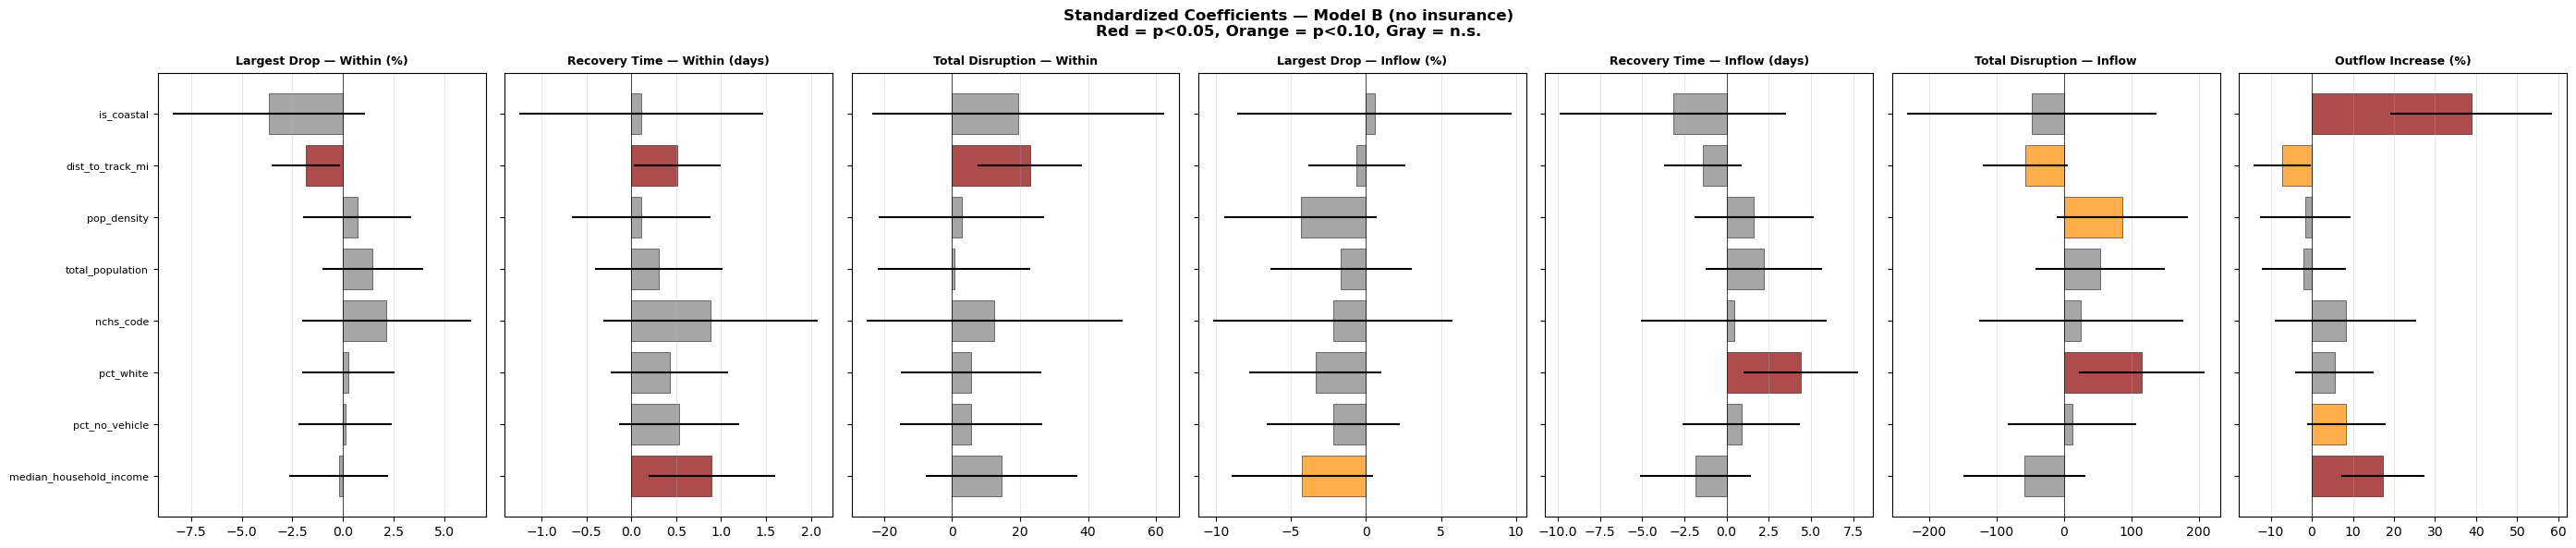

In [14]:
# ── Coefficient plot: Model B (no insurance) for all DVs ──
model_b = ols_df[ols_df['model'] == 'A'].copy()
dvs = list(DV_CONFIGS.values())
vars_to_plot = [v for v in X_BASE if v != 'is_milton']

fig, axes = plt.subplots(1, len(dvs), figsize=(4 * len(dvs), 6), sharey=True)

for ax, dv_label in zip(axes, dvs):
    sub = model_b[model_b['dv'] == dv_label]
    sub = sub[sub['variable'].isin(vars_to_plot)]
    if sub.empty:
        ax.set_title(dv_label, fontsize=9)
        continue
    
    y_pos = range(len(sub))
    colors = ['darkred' if p < 0.05 else 'darkorange' if p < 0.1 else 'gray'
              for p in sub['p']]
    
    ax.barh(y_pos, sub['coef'], xerr=sub['se'] * 1.96,
            color=colors, edgecolor='black', linewidth=0.5, alpha=0.7)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub['variable'], fontsize=8)
    ax.set_title(dv_label, fontsize=9, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Standardized Coefficients — Model B (no insurance)\n'
             'Red = p<0.05, Orange = p<0.10, Gray = n.s.',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/coefficient_plot_model_B.png',
            dpi=150, bbox_inches='tight')
plt.show()